## 5: ReAct (Reasoning - Act Agent)

# ReAct Agents 

## What is a ReAct Agent?

A **ReAct agent** is an AI system that **alternates between reasoning and acting** to solve a problem.

- **Reasoning (Thought):** The AI thinks about what to do next.
- **Action:** The AI performs an action using a tool (search, API, calculator, etc.).
- **Observation:** The AI looks at the result of that action.

This cycle repeats until the AI finds the final answer.

---

## Core Idea

**ReAct = Reasoning + Acting**

Instead of just generating text, the AI:

1. Thinks about the problem  
2. Chooses an action  
3. Uses a tool  
4. Observes the result  
5. Continues reasoning if needed  

---

## Basic Loop

```
Question
   ↓
Thought → What should I do?
   ↓
Action → Use a tool
   ↓
Observation → Result from the tool
   ↓
Thought → Decide next step
   ↓
Final Answer
```

---

## Simple Example

**Question:** What is the capital of France?

```
Thought: I should search for the capital of France.
Action: Search("capital of France")
Observation: Paris is the capital of France.

Thought: I now know the answer.
Final Answer: Paris
```

---

## Why ReAct Agents Are Useful

- They can **use external tools**
- They **reason step-by-step**
- They **adapt based on new information**
- They work well for **complex tasks**

---

## One-Line Summary

**A ReAct agent is an AI that thinks, takes actions using tools, observes results, and repeats this process until it solves the task.**

In [2]:
from langchain_community.tools import WikipediaQueryRun,ArxivQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain.messages import HumanMessage
from langchain_core.tools import Tool

c:\Users\asus\OneDrive\Documents\Projects\AgenticAI\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
api_wrapper=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper)
print(arxiv.name)

arxiv


In [4]:
api_wiki=WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wiki)
print(wiki.name)

wikipedia


In [5]:
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"

In [7]:
#Custom function : multiply two numbers
def multiply(a,b):
    """Multiplies two numbers a and b.
    
    Args:
        a (int): The first number.
        b (int): The second number.
    
    Returns:
        int: The product of a and b."""
    return a * b
    
    

In [8]:
#Custom function : add two numbers
def add(a,b):
    """Adds two numbers a and b.
    
    Args:
        a (int): The first number.
        b (int): The second number.
        
    Returns:
        int: The sum of a and b.
    """
    return a + b

In [9]:
tools=[arxiv,wiki,multiply,add]

In [10]:
from langchain.agents import create_agent

In [11]:
llm_with_tools=create_agent(model="groq:llama-3.1-8b-instant",tools=tools)

In [12]:
from pydantic import BaseModel,Field
from langgraph.graph.message import add_messages,Annotated,AnyMessage

In [13]:
class State(BaseModel):
    messages:Annotated[list[AnyMessage],add_messages]=Field(...,description="The list of messages in the conversation")

In [14]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition

In [15]:
# Node definition
def tool_with_llm(state:State):
    response=llm_with_tools.invoke({"messages":state.messages})
    return {"messages":response["messages"]}

In [16]:
#Building the graph
builder=StateGraph(State)
builder.add_node("tool_with_llm",tool_with_llm)
builder.add_node("tools",ToolNode(tools=tools))
# Add edges
builder.add_edge(START,"tool_with_llm")
builder.add_conditional_edges("tool_with_llm",tools_condition)
builder.add_edge("tools","tool_with_llm")

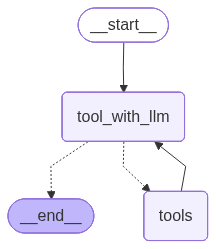

In [17]:
graph=builder.compile()
graph

In [18]:
results=graph.invoke({"messages":[HumanMessage(content="What is the news in kolkata today? and then add 5 and 10 and multiply the result with 3")]})

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [19]:
for m in results["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the news in kolkata today? and then add 5 and 10 and multiply the result with 3
================================== Ai Message ==================================
Tool Calls:
  wikipedia (64mbkk59w)
 Call ID: 64mbkk59w
  Args:
    query: kolkata news today
  add (xezfv5q4k)
 Call ID: xezfv5q4k
  Args:
    a: 5
    b: 10
  multiply (way046grw)
 Call ID: way046grw
  Args:
    a: 15
    b: 3
================================= Tool Message =================================
Name: wikipedia

Page: Kolkata
Summary: Kolkata, also known as Calcutta (its official name until 2001), is the capital and largest city of the Indian state of West Bengal. It lies on the eastern bank of the Hooghly River, 80 km (50 mi) west of the border with Bangladesh. It is the primary financial and commercial centre of eastern and one of the gateways to northeastern India. Kolkata is the seventh most populous city in India with an 

In [21]:
messages=[HumanMessage(content="multiply 3 with 10")]
messages=graph.invoke({"messages":messages})
for m in messages["messages"]:
    m.pretty_print()

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTP

================================ Human Message =================================

multiply 3 with 10
================================== Ai Message ==================================
Tool Calls:
  multiply (p5c4ytqvq)
 Call ID: p5c4ytqvq
  Args:
    a: 3
    b: 10
================================= Tool Message =================================
Name: multiply

30
================================== Ai Message ==================================
Tool Calls:
  add (p2dtpf6az)
 Call ID: p2dtpf6az
  Args:
    a: 30
    b: 5
================================= Tool Message =================================
Name: add

35
================================== Ai Message ==================================
Tool Calls:
  add (zw5w18hk2)
 Call ID: zw5w18hk2
  Args:
    a: 35
    b: 5
================================= Tool Message =================================
Name: add

40
================================== Ai Message ==================================
Tool Calls:
  wikipedia (0sa9fqaka)
 Call ID: 0sa

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')



At each stage, the system generates **state information** such as:

- User messages  
- Tool outputs  
- Intermediate reasoning  
- System responses  

Without memory management, the agent would **lose context between steps**.

---

## What MemorySaver Does

MemorySaver acts as a **checkpoint manager** that stores the workflow state during execution.

It enables the system to:

- Save agent workflow progress
- Maintain conversation context
- Resume interrupted workflows
- Track intermediate reasoning steps
- Support multi-step agent execution

> MemorySaver = temporary storage for agent workflow state.

---

## Example Usage in LangGraph

MemorySaver is commonly used when compiling a LangGraph workflow.

```python
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

app = workflow.compile(checkpointer=memory)
```

## What Happens here?

- Every step in the workflow is checkpointed

- The state is stored per thread/session

- The agent can resume with the same context

## Key Components Stored in Memory

#### MemorySaver typically stores:

- Conversation messages

- Agent state

- Tool responses

- Intermediate reasoning

- Workflow progress

This ensures the agent maintains continuity across multiple steps.

## Important Limitation

#### MemorySaver stores data only in RAM.

This means:

- Data is lost when the application stops

- It is not suitable for production environments

- It is primarily used for development and experimentation

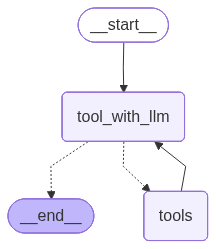

In [23]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
graph=builder.compile(checkpointer=memory)
graph

In [24]:
## Specify the thread
config={"configurable":{"thread_id":"1234"}}
messages=[HumanMessage(content="Add 12 and 13")]
messages=graph.invoke({"messages":messages},config=config)
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13
================================== Ai Message ==================================
Tool Calls:
  add (wh2104ebz)
 Call ID: wh2104ebz
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The result of 'add' function is 25.


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [25]:
## Specify the thread
config={"configurable":{"thread_id":"1234"}}
messages=[HumanMessage(content="Multiply 10 with it")]
messages=graph.invoke({"messages":messages},config=config)
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13
================================== Ai Message ==================================
Tool Calls:
  add (wh2104ebz)
 Call ID: wh2104ebz
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The result of 'add' function is 25.
================================ Human Message =================================

Multiply 10 with it
================================== Ai Message ==================================
Tool Calls:
  multiply (csxyyv3m1)
 Call ID: csxyyv3m1
  Args:
    a: 25
    b: 10
================================= Tool Message =================================
Name: multiply

250
================================== Ai Message ==================================

The result of 'multiply' function is 250.


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


## Streaming using astream vs astream_events

| Concept            | Analogy                                                  |
| ------------------ | -------------------------------------------------------- |
| `astream()`        | Watching a message being typed                           |
| `astream_events()` | Watching **everything the agent does behind the scenes** |


### When building agentic systems

#### Use:

**astream():**

- Chatbots

- Streaming responses

- UI typing effect

**astream_events():**

- Debugging agents

- Observing tool usage

- Building agent dashboards

- Visualizing reasoning